# Main.ipynb

## 1. Comparison of Mean Delicassen Expenditure by Frozen Food User Segment

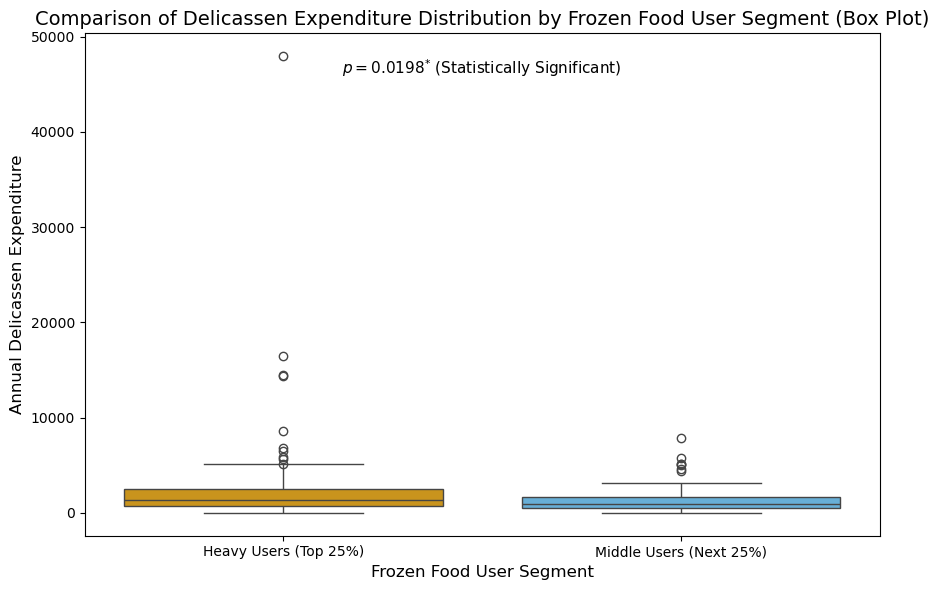

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Wholesale customers data.csv")

Q_50 = df['Frozen'].quantile(0.50)
Q_75 = df['Frozen'].quantile(0.75)

heavy_users_df = df[df['Frozen'] > Q_75].copy()
heavy_users_df['User_Segment'] = 'Heavy Users (Top 25%)'

middle_users_df = df[(df['Frozen'] > Q_50) & (df['Frozen'] <= Q_75)].copy()
middle_users_df['User_Segment'] = 'Middle Users (Next 25%)'

plot_df = pd.concat([heavy_users_df, middle_users_df])

plt.figure(figsize=(9, 6))

sns.boxplot(x='User_Segment', y='Delicassen', data=plot_df,
            hue='User_Segment', legend=False,
            order=['Heavy Users (Top 25%)', 'Middle Users (Next 25%)'],
            palette=['#E69F00', '#56B4E9']) 

plt.title('Comparison of Delicassen Expenditure Distribution by Frozen Food User Segment (Box Plot)', fontsize=14)
plt.xlabel('Frozen Food User Segment', fontsize=12)
plt.ylabel('Annual Delicassen Expenditure', fontsize=12)

y_max_delicassen = plot_df['Delicassen'].max()
plt.text(0.5, y_max_delicassen * 0.95, '$p = 0.0198^{*}$ (Statistically Significant)', 
         ha='center', va='bottom', fontsize=11, color='k')

plt.tight_layout()
plt.savefig("delicassen_frozen_comparison_boxplot_no_cleaning.png")

### Conclusion:
The p-value is smaller than 0.05.Therefore, the null hypothesis is rejected.This result indicates that Heavy Frozen Food Users have a statistically significantly higher mean annual expenditure on Delicassen compared to Middle Frozen Food Users. This suggests a specific business insight: the purchasing strategy of customers who stock large volumes of frozen food is correlated with higher expenditure on value-added goods, such as delicatessen items.

## 2. Comparing Mean Fresh Spending Between High and Low Grocery Dependence Segments

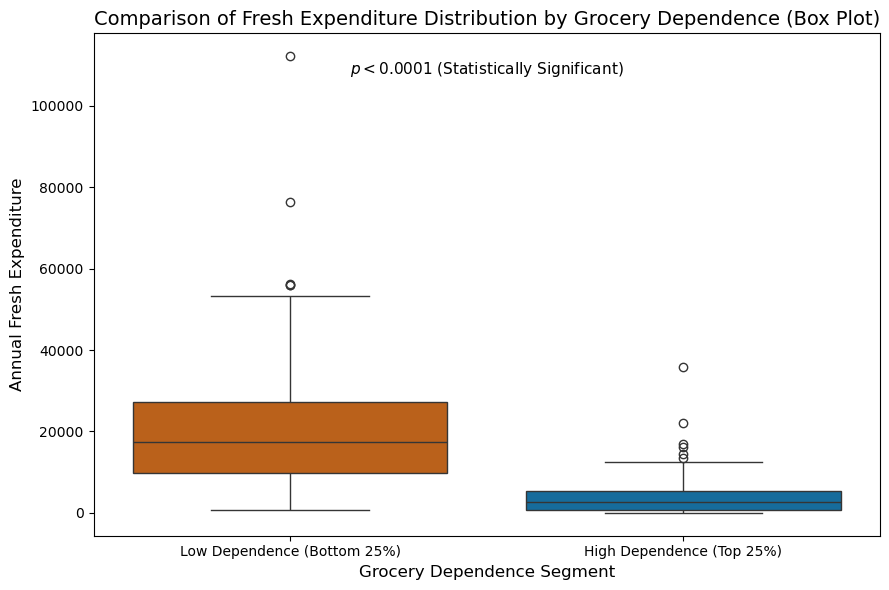

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Wholesale customers data.csv")

spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
df['Total_Spending'] = df[spending_cols].sum(axis=1)
df['Grocery_Ratio'] = df['Grocery'] / df['Total_Spending']

q_25 = df['Grocery_Ratio'].quantile(0.25)
q_75 = df['Grocery_Ratio'].quantile(0.75)

high_ratio_df = df[df['Grocery_Ratio'] > q_75].copy()
high_ratio_df['Segment'] = 'High Dependence (Top 25%)'

low_ratio_df = df[df['Grocery_Ratio'] < q_25].copy()
low_ratio_df['Segment'] = 'Low Dependence (Bottom 25%)'

plot_df = pd.concat([high_ratio_df, low_ratio_df])

plt.figure(figsize=(9, 6))
sns.boxplot(x='Segment', y='Fresh', data=plot_df,
            hue='Segment', legend=False,
            order=['Low Dependence (Bottom 25%)', 'High Dependence (Top 25%)'],
            palette=['#0072B2', '#D55E00'])

plt.title('Comparison of Fresh Expenditure Distribution by Grocery Dependence (Box Plot)', fontsize=14)
plt.xlabel('Grocery Dependence Segment', fontsize=12)
plt.ylabel('Annual Fresh Expenditure', fontsize=12)

y_max_fresh = plot_df['Fresh'].max()
plt.text(0.5, y_max_fresh * 0.95, '$p < 0.0001$ (Statistically Significant)', 
         ha='center', va='bottom', fontsize=11, color='k')

plt.tight_layout()
plt.savefig("fresh_grocery_dependence_boxplot_en.png")

### Conclusion:
The p-value is significantly smaller than 0.05, leading to the rejection of the null hypothesis.This result indicates that the Low Grocery Dependence customer segment has a statistically significantly higher mean expenditure on Fresh products than the High Grocery Dependence segment. This result provides a specific business insight:
A low grocery dependence (meaning a small proportion of total spending is on Grocery) implies that a customer's spending is disproportionately allocated to other categories, such as Fresh, Frozen, and Milk. This segment likely represents Horeca (Hotel, Restaurant, Cafe) channel customers or those prioritizing non-retail-centric sourcing. This clearly confirms a distinct purchasing strategy compared to customers focused primarily on grocery items (retail stores).